In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sahal00/responsible-gaming-cleaned/cleaned_dataset.parquet


In [2]:
#df= pd.read_csv("/kaggle/input/datasets/ccanb23/bcgame-crash-dataset/bets.csv")

#df.shape


#df=df.drop(['crypto_bet_amount','crypto_win_amount'	,'crypto_profit_amount'],axis=1)

#df.head()

#df.isna().sum()

#df = df.dropna(subset=[
   # "fiat_bet_amount",
   # "fiat_profit_amount",
    #"fiat_profit_amount",
#])
#df = df.drop(['id'],axis=1)

#df.isna().sum()

#print((df['fiat_is_valuable']=="f" ).sum())
#print((df['fiat_currency_name']=="jb" ).sum())

#df = df.reset_index(drop=True)

#df.head(100)
#df['fiat_currency_name'].value_counts()

#counts = df[['user_id', 'username']].value_counts()
#print(counts)

#print(df.loc[df['username'].isna(), 'user_id'].unique())

#df.groupby('user_id')['username'].unique()
#df.loc[df['user_id'] == 185893, 'username'] = 'john_smith'

#df.head(900)
#
#df=df.drop(['username'],axis=1)

#print(df.shape)

#size_mb = df.memory_usage(deep=True).sum() / 1024**2
#print(f"RAM usage: {size_mb:.2f} MB")

#df.to_parquet(
   # '/kaggle/working/cleaned_dataset.parquet',
  #  index=False
#)

#import os

#print(os.listdir('/kaggle/working'))

#import os

#size_mb = os.path.getsize(
   # '/kaggle/working/cleaned_dataset.parquet'
##) / (1024**2)

#print(f"Parquet size: {size_mb:.2f} MB")


In [3]:
USE_CLEANED_FILE = True

In [4]:
if USE_CLEANED_FILE:
    df = pd.read_parquet('/kaggle/input/datasets/sahal00/responsible-gaming-cleaned')
    df = df.drop(['fiat_is_valuable','fiat_currency_name'],axis=1)
    
else:
    df = pd.read_csv('/kaggle/input/datasets/ccanb23/bcgame-crash-dataset/bets.csv')

   

    df.to_parquet(
    '/kaggle/working/cleaned_dataset.parquet',
    index=False)

In [5]:
df.columns.value_counts()

game_id                 1
user_id                 1
bet_id                  1
game_type               1
odds                    1
bet_status              1
crypto_currency_name    1
fiat_bet_amount         1
fiat_profit_amount      1
Name: count, dtype: int64


# Now performing eda after cleaning the data , targets-How much users bet.


1. How often do users bet.

2. How much do users lose.

3. Are they escalating stake sizes ?

4. Are they chasing losses ?

 **ALL FIAT CURRENCY IS USD**

In [6]:
df.head()

,game_id,user_id,bet_id,game_type,odds,bet_status,crypto_currency_name,fiat_bet_amount,fiat_profit_amount
0,2828375,173570,210854317,normal,0.0,lose,ltc,0.048738,-0.048738
1,2828375,1139219,210854260,normal,2.0,win,xlm,0.000088,0.000088
2,2828375,1329183,12148544,yellow,0.0,lose,doge,0.188109,-0.188109
3,2828375,1378328,210854292,normal,0.0,lose,doge,0.000005,-0.000005
4,2828375,1420292,210854342,normal,3.0,win,ltc,0.000107,0.000213


In [7]:
print('number of unqiue users:',df['user_id'].nunique())

number of unqiue users: 32102


In [8]:
df_sorted=df.sort_values(by=['user_id', 'bet_id']).copy()


In [9]:
# Useing groupby + shift to map the previous bet's status and size onto the current row
# This guarantees User B's first bet doesn't accidentally look at User A's last bet
df_sorted['prev_bet_status'] = df_sorted.groupby('user_id')['bet_status'].shift(1)
df_sorted['prev_fiat_bet_amount'] = df_sorted.groupby('user_id')['fiat_bet_amount'].shift(1)

In [10]:
df_filtered = df_sorted[df_sorted['prev_fiat_bet_amount'] >= 0.01].copy()

In [11]:
df_sorted.head()

,game_id,user_id,bet_id,game_type,odds,bet_status,crypto_currency_name,fiat_bet_amount,fiat_profit_amount,prev_bet_status,prev_fiat_bet_amount
994167,2831698,44,212042687,normal,1.03,win,eth,0.000034,0.000001,NaN,NaN
1015409,2831768,44,212067364,normal,1.03,win,eth,0.000034,0.000001,win,0.000034
1031326,2831820,44,212085405,normal,1.08,win,eth,0.000034,0.000003,win,0.000034
1289324,2832628,44,212376980,normal,1.67,win,eth,0.000035,0.000024,win,0.000034
1308211,2832686,44,212397916,normal,2.00,win,eth,0.000140,0.000140,win,0.000035


In [12]:
#Calculating the percentage change in bet size compared to their previous bet
# Formula: ((Current Bet - Previous Bet) / Previous Bet) * 100
df_filtered['bet_pct_change'] = (
    (df_filtered['fiat_bet_amount'] - df_filtered['prev_fiat_bet_amount']) 
    / df_filtered['prev_fiat_bet_amount']
) * 100

In [13]:
df_sorted.head()

,game_id,user_id,bet_id,game_type,odds,bet_status,crypto_currency_name,fiat_bet_amount,fiat_profit_amount,prev_bet_status,prev_fiat_bet_amount
994167,2831698,44,212042687,normal,1.03,win,eth,0.000034,0.000001,NaN,NaN
1015409,2831768,44,212067364,normal,1.03,win,eth,0.000034,0.000001,win,0.000034
1031326,2831820,44,212085405,normal,1.08,win,eth,0.000034,0.000003,win,0.000034
1289324,2832628,44,212376980,normal,1.67,win,eth,0.000035,0.000024,win,0.000034
1308211,2832686,44,212397916,normal,2.00,win,eth,0.000140,0.000140,win,0.000035


In [14]:
#Cleaning up boundary anomalies (drop NaNs from the first bet of every user, handle division by zero)
df_filtered['bet_pct_change'] = df_filtered['bet_pct_change'].replace([np.inf, -np.inf], np.nan)
df_clean = df_filtered.dropna(subset=['prev_bet_status', 'bet_pct_change'])

In [15]:
# Filtering out extreme percentage spikes (ignore anything over a 1000% jump)
df_clean = df_clean[(df_clean['bet_pct_change'] >= -100) & (df_clean['bet_pct_change'] <= 1000)]

In [16]:
df_sorted.head()

,game_id,user_id,bet_id,game_type,odds,bet_status,crypto_currency_name,fiat_bet_amount,fiat_profit_amount,prev_bet_status,prev_fiat_bet_amount
994167,2831698,44,212042687,normal,1.03,win,eth,0.000034,0.000001,NaN,NaN
1015409,2831768,44,212067364,normal,1.03,win,eth,0.000034,0.000001,win,0.000034
1031326,2831820,44,212085405,normal,1.08,win,eth,0.000034,0.000003,win,0.000034
1289324,2832628,44,212376980,normal,1.67,win,eth,0.000035,0.000024,win,0.000034
1308211,2832686,44,212397916,normal,2.00,win,eth,0.000140,0.000140,win,0.000035


In [17]:
df_clean.head()

,game_id,user_id,bet_id,game_type,odds,bet_status,crypto_currency_name,fiat_bet_amount,fiat_profit_amount,prev_bet_status,prev_fiat_bet_amount,bet_pct_change
9937198,2860133,44,222184751,normal,1.78,win,eth,0.000039,0.000030,win,0.038880,-99.9
11036499,2863704,44,223464868,normal,0.00,lose,eth,0.766346,-0.766346,lose,0.383173,100.0
11036844,2863705,44,223465475,normal,2.10,win,eth,1.532691,1.685961,lose,0.766346,100.0
11037194,2863706,44,223465813,normal,1.03,win,eth,0.383173,0.011495,win,1.532691,-75.0
11037544,2863707,44,223466196,normal,1.03,win,eth,0.383173,0.011495,win,0.383173,0.0


In [18]:
# Grouping by the PREVIOUS outcome to see how they reacted to that Win or Loss
loss_chasing_results = df_clean.groupby('prev_bet_status', observed=False)['bet_pct_change'].median().reset_index()

In [19]:
 import plotly.express as px

In [20]:
fig = px.bar(
    loss_chasing_results,
    x='prev_bet_status',
    y='bet_pct_change',
    color='prev_bet_status',
    title='The Loss-Chasing Trigger: Typical Behavioral Adjustments (Outliers Removed)',
    labels={
        'prev_bet_status': 'Previous Bet Outcome', 
        'bet_pct_change': 'Median % Change in Next Wager'
    },
    color_discrete_map={'lose': '#EF553B', 'win': '#636EFA'}
)

fig.update_layout(
    template='plotly_dark',
    xaxis_title="Outcome of the Previous Round",
    yaxis_title="Median % Shift in Next Bet Size",
    showlegend=False
)

fig.show()

In [21]:
df.head()

,game_id,user_id,bet_id,game_type,odds,bet_status,crypto_currency_name,fiat_bet_amount,fiat_profit_amount
0,2828375,173570,210854317,normal,0.0,lose,ltc,0.048738,-0.048738
1,2828375,1139219,210854260,normal,2.0,win,xlm,0.000088,0.000088
2,2828375,1329183,12148544,yellow,0.0,lose,doge,0.188109,-0.188109
3,2828375,1378328,210854292,normal,0.0,lose,doge,0.000005,-0.000005
4,2828375,1420292,210854342,normal,3.0,win,ltc,0.000107,0.000213


In [22]:
user_bet_distribution = df_clean.groupby('user_id').agg(
    total_fiat_wagered=('fiat_bet_amount', 'sum'),
    max_fiat_wager=('fiat_bet_amount', 'max'),
    total_bets_placed=('bet_id', 'count')
).reset_index()

In [23]:
print(user_bet_distribution[['total_fiat_wagered', 'max_fiat_wager']].describe())

       total_fiat_wagered  max_fiat_wager
count        1.728500e+04    1.728500e+04
mean         6.186143e+02    1.072921e+01
std          1.473846e+04    1.549285e+02
min          9.814027e-13    9.814027e-13
25%          6.094659e-02    2.771928e-02
50%          5.589617e-01    1.099240e-01
75%          1.224472e+01    1.122760e+00
max          1.342043e+06    1.388299e+04


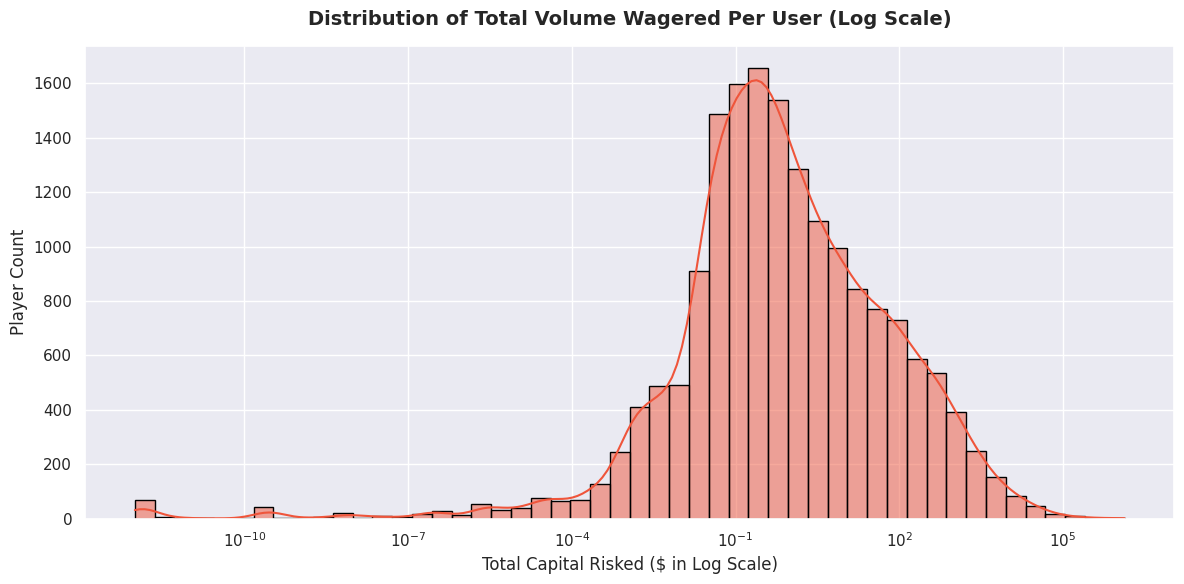

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# histogram using Seaborn for distribution of volume wagered
ax = sns.histplot(
    data=user_bet_distribution,
    x="total_fiat_wagered",
    log_scale=True,  
    kde=True,
    bins=50,
    color="#EF553B",  
    edgecolor="black",
)

plt.title(
    "Distribution of Total Volume Wagered Per User (Log Scale)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Total Capital Risked ($ in Log Scale)", fontsize=12)
plt.ylabel("Player Count", fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
df_clean.head()


,game_id,user_id,bet_id,game_type,odds,bet_status,crypto_currency_name,fiat_bet_amount,fiat_profit_amount,prev_bet_status,prev_fiat_bet_amount,bet_pct_change
9937198,2860133,44,222184751,normal,1.78,win,eth,0.000039,0.000030,win,0.038880,-99.9
11036499,2863704,44,223464868,normal,0.00,lose,eth,0.766346,-0.766346,lose,0.383173,100.0
11036844,2863705,44,223465475,normal,2.10,win,eth,1.532691,1.685961,lose,0.766346,100.0
11037194,2863706,44,223465813,normal,1.03,win,eth,0.383173,0.011495,win,1.532691,-75.0
11037544,2863707,44,223466196,normal,1.03,win,eth,0.383173,0.011495,win,0.383173,0.0


In [26]:
# Aggregating net returns per user
user_losses = df_clean.groupby('user_id').agg(
    total_net_profit=('fiat_profit_amount', 'sum'),
    total_bets_placed=('bet_id', 'count')
).reset_index()

user_losses.head()


,user_id,total_net_profit,total_bets_placed
0,44,0.942637,6
1,5588,-1215.536690,5222
2,5977,4.643415,22
3,9388,0.004361,3
4,9699,45.304427,1690


In [27]:
# Filter for users who are net net LOSERS (profit < 0)
#  Then Converting to a positive 'net_loss' value for plotting
user_losses['net_loss'] = user_losses['total_net_profit'].apply(lambda x: abs(x) if x < 0 else 0)
net_losers_df = user_losses[user_losses['net_loss'] > 0].copy()

# Print metrics to check the scale of losses
print(f"Total Unique Users: {len(user_losses)}")
print(f"Number of Net Losers: {len(net_losers_df)} ({len(net_losers_df)/len(user_losses)*100:.1f}%)")
print(net_losers_df['net_loss'].describe())

net_losers_df.head()

Total Unique Users: 17285
Number of Net Losers: 12680 (73.4%)
count    1.268000e+04
mean     2.182065e+01
std      5.324837e+02
min      4.336809e-19
25%      3.132157e-02
50%      1.164072e-01
75%      1.344691e+00
max      5.699808e+04
Name: net_loss, dtype: float64


,user_id,total_net_profit,total_bets_placed,net_loss
1,5588,-1215.536690,5222,1215.536690
7,14857,-0.023597,33,0.023597
8,17144,-9.900172,14,9.900172
9,23503,-0.000003,1,0.000003
14,27721,-0.060883,5,0.060883


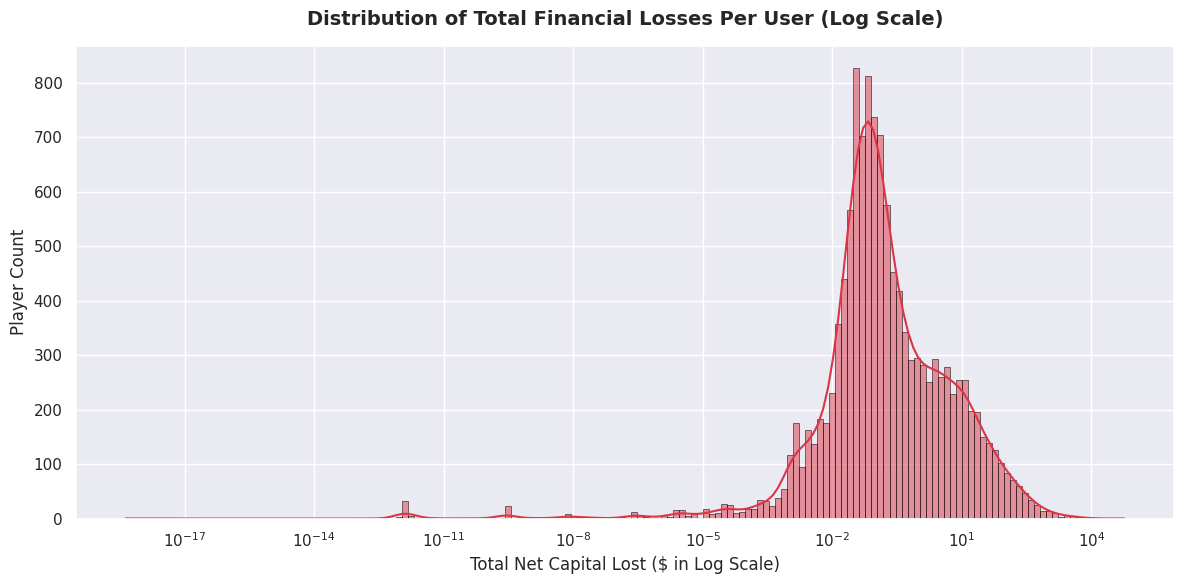

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# Plotting the histogram for financial losses
ax = sns.histplot(
    data=net_losers_df,
    x="net_loss",
    log_scale=True,  
    kde=True,        
    color="#DC3545",  
    edgecolor="black"
)

plt.title(
    "Distribution of Total Financial Losses Per User (Log Scale)",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.xlabel("Total Net Capital Lost ($ in Log Scale)", fontsize=12)
plt.ylabel("Player Count", fontsize=12)

plt.tight_layout()
plt.show()

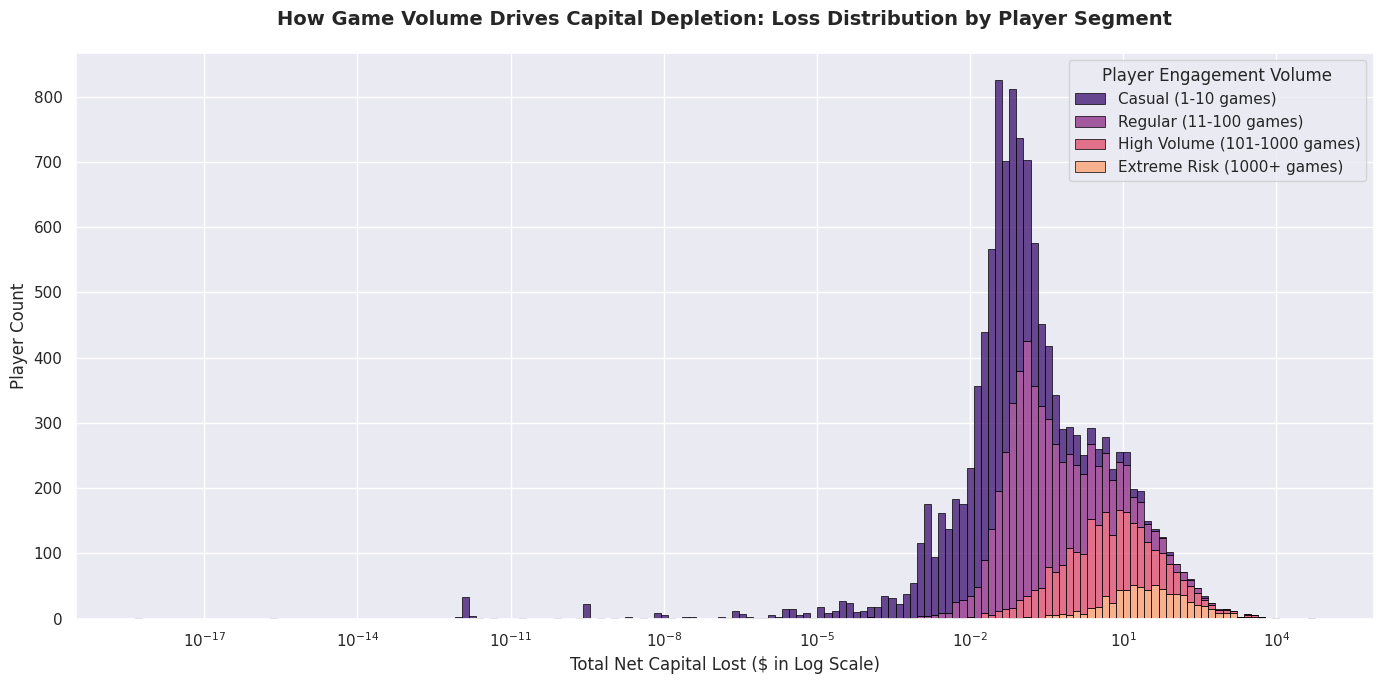

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Bin the continuous game counts into meaningful behavioral segments
bins = [0, 10, 100, 1000, np.inf]
labels = [
    "Casual (1-10 games)",
    "Regular (11-100 games)",
    "High Volume (101-1000 games)",
    "Extreme Risk (1000+ games)",
]

net_losers_df["volume_segment"] = pd.cut(
    net_losers_df["total_bets_placed"], bins=bins, labels=labels
)

sns.set_theme(style="darkgrid")
plt.figure(figsize=(14, 7))

# Plotting the histogram with the categorical hue
# We use multiple="stack" so to see exactly who makes up the heavy loss tail
sns.histplot(
    data=net_losers_df,
    x="net_loss",
    hue="volume_segment",
    log_scale=True,  
    multiple="stack",  
    palette="magma",
    edgecolor="black",
    linewidth=0.5,
)

plt.title(
    "How Game Volume Drives Capital Depletion: Loss Distribution by Player Segment",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Total Net Capital Lost ($ in Log Scale)", fontsize=12)
plt.ylabel("Player Count", fontsize=12)


sns.move_legend(plt.gca(), "upper right", title="Player Engagement Volume")

plt.tight_layout()
plt.show()

In [30]:
df_clean.head()

,game_id,user_id,bet_id,game_type,odds,bet_status,crypto_currency_name,fiat_bet_amount,fiat_profit_amount,prev_bet_status,prev_fiat_bet_amount,bet_pct_change
9937198,2860133,44,222184751,normal,1.78,win,eth,0.000039,0.000030,win,0.038880,-99.9
11036499,2863704,44,223464868,normal,0.00,lose,eth,0.766346,-0.766346,lose,0.383173,100.0
11036844,2863705,44,223465475,normal,2.10,win,eth,1.532691,1.685961,lose,0.766346,100.0
11037194,2863706,44,223465813,normal,1.03,win,eth,0.383173,0.011495,win,1.532691,-75.0
11037544,2863707,44,223466196,normal,1.03,win,eth,0.383173,0.011495,win,0.383173,0.0


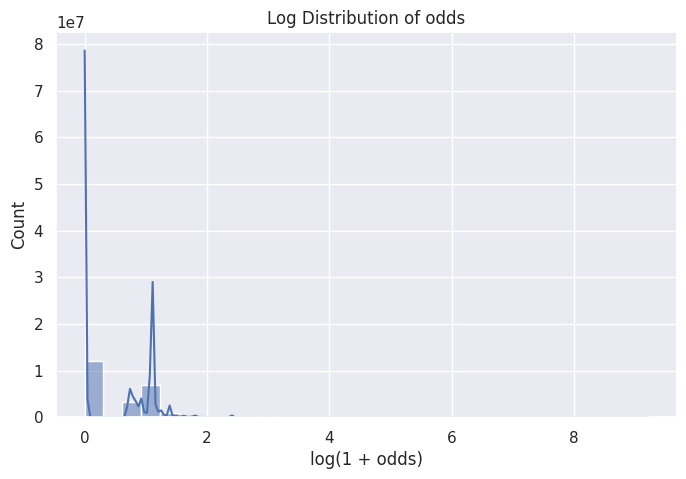

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(
    np.log1p(df_sorted['odds']),
    bins=30,
    kde=True
)

plt.title('Log Distribution of odds')
plt.xlabel('log(1 + odds)')
plt.show()

In [32]:
df_clean['odds'].nlargest(20)

10663219    1001.00
3092842     1000.00
16500339    1000.00
18640942     576.96
17702745     551.21
14987653     543.23
18230123     500.00
10067821     500.00
3092759      500.00
22199898     500.00
15194370     481.25
15783922     465.63
15809760     450.62
21011295     428.42
18205213     415.96
17633727     414.49
15719396     411.76
16191461     400.00
19487896     400.00
16420858     400.00
Name: odds, dtype: float64

# Is there any value for multiplier to get good returns(over time)?

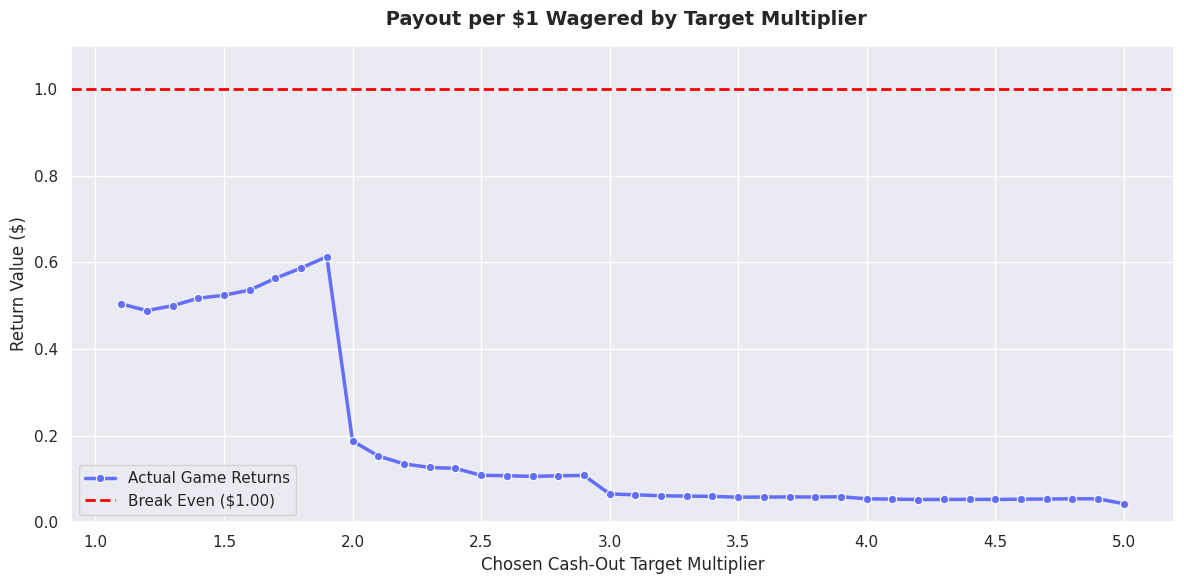

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


target_multipliers = np.arange(1.1, 5.1, 0.1)
empirical_returns = []

    # Calculating hypothetical payouts across all game rounds
for target in target_multipliers:
    payouts = np.where(df_sorted['odds'] >= target, target, 0)
    mean_return = np.mean(payouts)
    empirical_returns.append(mean_return)


sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

sns.lineplot(x=target_multipliers, y=empirical_returns, marker='o', color='#636EFA', linewidth=2.5, label='Actual Game Returns')
plt.axhline(1.0, linestyle='--', color='red', linewidth=2, label='Break Even ($1.00)')



plt.ylim(0.00, 1.10)
plt.title(" Payout per $1 Wagered by Target Multiplier", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Chosen Cash-Out Target Multiplier", fontsize=12)
plt.ylabel("Return Value ($)", fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [34]:
print("First 5 values of empirical_returns:", empirical_returns[:30])
print("Length of list:", len(empirical_returns))



First 5 values of empirical_returns: [np.float64(0.5040359147552931), np.float64(0.4887528601824381), np.float64(0.4998506251563042), np.float64(0.5172289728060481), np.float64(0.5241630672091666), np.float64(0.5361371591714132), np.float64(0.5632082792179134), np.float64(0.5869845650851453), np.float64(0.613176517030138), np.float64(0.18767467703442992), np.float64(0.15305455657123332), np.float64(0.13477702447094023), np.float64(0.12655659145958828), np.float64(0.12434922225492344), np.float64(0.10835750493530923), np.float64(0.1074771926751219), np.float64(0.1059054614679068), np.float64(0.10726185086992919), np.float64(0.10806648581817466), np.float64(0.06541502277775678), np.float64(0.06330524559473201), np.float64(0.06121596899269987), np.float64(0.06031117516495173), np.float64(0.05972893980971145), np.float64(0.057820080319082326), np.float64(0.05820723447676642), np.float64(0.05845752668717985), np.float64(0.05829947852075627), np.float64(0.05889460387340998), np.float64(0.054

*The game basically ups the chances to win the dollar back till x1.9(which is still 0.61) then instantly plummets when reaching 2x(just 0.18)
after that 2x it is impossible to recover the money spent as it just plummets more extremely*

# SWEET SPOT?

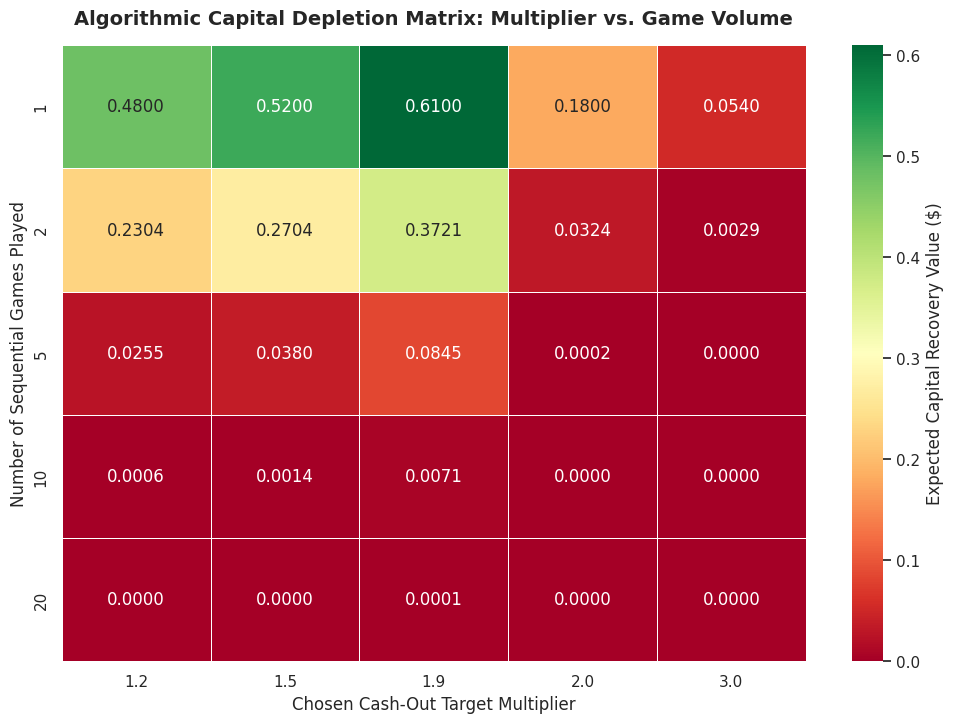

In [35]:

# Defineing  space
target_multipliers = np.array([1.2, 1.5, 1.9, 2.0, 3.0])
game_volumes = np.array([1, 2, 5, 10, 20])

empirical_returns_map = {1.2: 0.48, 1.5: 0.52, 1.9: 0.61, 2.0: 0.18, 3.0: 0.054}

# Building a matrx for optimizing
matrix_data = []
for games in game_volumes:
    row = []
    for mult in target_multipliers:
        # Expected money recovery compounding over many games
        base_return = empirical_returns_map[mult]
        expected_recovery = (base_return) ** games
        row.append(expected_recovery)
    matrix_data.append(row)

df_matrix = pd.DataFrame(matrix_data, index=game_volumes, columns=target_multipliers)

#  Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_matrix, 
    annot=True, 
    fmt=".4f", 
    cmap="RdYlGn", 
    linewidths=0.5,
    cbar_kws={'label': 'Expected Capital Recovery Value ($)'}
)

plt.title("Algorithmic Capital Depletion Matrix: Multiplier vs. Game Volume", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Chosen Cash-Out Target Multiplier", fontsize=12)
plt.ylabel("Number of Sequential Games Played", fontsize=12)
plt.show()

Above heatmap shows that one game at 1.9x is the sweet spot that feels like the has the maximum probability of winning but 
 > Expected return = (Payout if Win x Probabilit_of_win)+(Payout if Loss x Probability_of_loss)
 
> 0.54 =(1.90 *Pwin) +(0 * Pl)
>
> Pwin=32%


In [36]:


total_games = len(df_sorted)

starting_multipliers = [1.01, 1.05, 1.10, 1.20, 1.30, 1.50,1.90, 2.00, 3.00]

print(f"Analyzing {total_games:,} total game rounds...\n")
print(f"{'Target Multiplier':<20} | {'Actual Win Probability (Empirical)':<35} | {'Theoretical Fair Prob':<20}")
print("-" * 85)


for target in starting_multipliers:
    # Counting how many games crashed at or above the target
    successful_runs = np.sum(df_sorted['odds'] >= target)
    
    # Calculating empirical probability
    empirical_prob = (successful_runs / total_games) * 100
    
    # Calculating what fair game should be
    fair_prob = (1 / target) * 100
    
    print(f"{target:<20.2f}x | {empirical_prob::<35.2f}% | {fair_prob:<20.2f}%")

Analyzing 23,335,924 total game rounds...

Target Multiplier    | Actual Win Probability (Empirical)  | Theoretical Fair Prob
-------------------------------------------------------------------------------------
1.01                x | 48.17::::::::::::::::::::::::::::::% | 99.01               %
1.05                x | 47.00::::::::::::::::::::::::::::::% | 95.24               %
1.10                x | 45.82::::::::::::::::::::::::::::::% | 90.91               %
1.20                x | 42.07::::::::::::::::::::::::::::::% | 83.33               %
1.30                x | 39.40::::::::::::::::::::::::::::::% | 76.92               %
1.50                x | 36.59::::::::::::::::::::::::::::::% | 66.67               %
1.90                x | 32.42::::::::::::::::::::::::::::::% | 52.63               %
2.00                x | 29.17::::::::::::::::::::::::::::::% | 50.00               %
3.00                x | 3.62:::::::::::::::::::::::::::::::% | 33.33               %


***so according to the table above we can conclude that the highest winning probability is at 1.01x but it takes** -*
> (1/0.01)= 100 games  to profit of 1 dollar But there is  a 1 percent chance(more that that in actual casinos) that game will crash
>
> and the player will lose the entire 1 dollar at stake
>
> making the player even more cornered to recover the dollar making it move towards the higher multipliers where the probability is already very low
>
> If resonably saying the least risk is playing a single game at 1.01x to win a cent , but the profit is not worth
>
> if the capital is very large the value at risk becomes very High , because if loss the entire capital will deplete.

# THE ABOVE EDA CONCLUDES
**End-to-end processing of 23+ million data points, the empirical evidence proves that platform profitability relies entirely on exploiting the human psychological failure mode of *loss-chasing***

In [37]:
df_sorted.head()

,game_id,user_id,bet_id,game_type,odds,bet_status,crypto_currency_name,fiat_bet_amount,fiat_profit_amount,prev_bet_status,prev_fiat_bet_amount
994167,2831698,44,212042687,normal,1.03,win,eth,0.000034,0.000001,NaN,NaN
1015409,2831768,44,212067364,normal,1.03,win,eth,0.000034,0.000001,win,0.000034
1031326,2831820,44,212085405,normal,1.08,win,eth,0.000034,0.000003,win,0.000034
1289324,2832628,44,212376980,normal,1.67,win,eth,0.000035,0.000024,win,0.000034
1308211,2832686,44,212397916,normal,2.00,win,eth,0.000140,0.000140,win,0.000035


# Now we make metrics for training model to identify destructive players
1. total_bets= total number of rounds played
2. total net loss = total money loss
3. wager_volatility = std deviviationi of their wagerers / mean wages
4. loss chasing ratio = avg % increase in a user's bet size immedietly following a loss
5. scalper_ratio = % of bets placed at ultra low multipliers (>=1.10x)
6. High risk targets = flag users who fall into the top 5 % of financial losses as 1 and others as 0


In [38]:
import numpy as np
import pandas as pd

print("Executing In-Memory Feature Engineering Pipeline...")


df_sorted["prev_bet_status"] = df_sorted.groupby("user_id")[
    "bet_status"
].shift(1)
df_sorted["prev_fiat_bet_amount"] = df_sorted.groupby("user_id")[
    "fiat_bet_amount"
].shift(1)

df_sorted["bet_pct_change"] = (
    (df_sorted["fiat_bet_amount"] - df_sorted["prev_fiat_bet_amount"])
    / (df_sorted["prev_fiat_bet_amount"] + 1e-5)
) * 100
df_sorted["bet_pct_change"] = (
    df_sorted["bet_pct_change"].replace([np.inf, -np.inf], np.nan).fillna(0)
)

df_sorted["loss_chase_val"] = np.where(
    df_sorted["prev_bet_status"] == "lose", df_sorted["bet_pct_change"], np.nan
)

# scalping behavior
df_sorted["is_scalp"] = (df_sorted["odds"] <= 1.10).astype(int)

print("Calculating user-level aggregations...")


df_global = (
    df_sorted.groupby("user_id")
    .agg(
        total_bets=("bet_id", "count"),
        total_wagered=("fiat_bet_amount", "sum"),
        total_net_profit=("fiat_profit_amount", "sum"),
        total_scalp_bets=("is_scalp", "sum"),
        
        global_bet_sum=("fiat_bet_amount", "sum"),
        global_bet_sq_sum=(
            "fiat_bet_amount",
            lambda x: np.sum(x**2),
        ), 
        global_loss_chase_sum=("loss_chase_val", "sum"),
        global_loss_count=("loss_chase_val", "count"),
    )
    .reset_index()
)

print("Deriving complex behavioral features...")

df_global["mean_bet"] = df_global["global_bet_sum"] / df_global["total_bets"]

df_global["bet_variance"] = (
    df_global["global_bet_sq_sum"] / df_global["total_bets"]
) - (df_global["mean_bet"] ** 2)
df_global["bet_std"] = np.sqrt(np.maximum(df_global["bet_variance"], 0))

df_global["wager_volatility"] = df_global["bet_std"] / (
    df_global["mean_bet"] + 1e-5
)

# Loss Chase Index (Average bet spike percentage specifically after losses)
df_global["loss_chase_ratio"] = df_global["global_loss_chase_sum"] / (
    df_global["global_loss_count"] + 1e-5
)

#Scalper Ratio (Percentage of total bets placed below 1.10x)
df_global["scalper_ratio"] = (
    df_global["total_scalp_bets"] / df_global["total_bets"]
)

# Droping intermediate tracking columns to clean up memory
df_global.drop(
    columns=[
        "global_bet_sum",
        "global_bet_sq_sum",
        "global_loss_chase_sum",
        "global_loss_count",
        "mean_bet",
        "bet_variance",
        "bet_std",
        "total_scalp_bets",
    ],
    inplace=True,
)

# target Column
df_global["net_loss"] = df_global["total_net_profit"].apply(
    lambda x: abs(x) if x < 0 else 0
)
loss_threshold = df_global["net_loss"].quantile(0.95)

# 1 = High Risk Profile (Top 5% financial losers), 0 = Regular Group
df_global["high_risk_target"] = (df_global["net_loss"] >= loss_threshold).astype(
    int
)

# Saving the training matrix
df_global.to_csv("model_training_features.csv", index=False)

print(
    f"\nSUCCESS! Matrix generated. High-Risk Loss Threshold Set at: ${loss_threshold:.2f}"
)
print(df_global["high_risk_target"].value_counts())

Executing In-Memory Feature Engineering Pipeline...
Calculating user-level aggregations...
Deriving complex behavioral features...

SUCCESS! Matrix generated. High-Risk Loss Threshold Set at: $10.15
high_risk_target
0    30496
1     1606
Name: count, dtype: int64


In [39]:
DF = pd.read_csv('/kaggle/working/model_training_features.csv')
DF.head()

,user_id,total_bets,total_wagered,total_net_profit,wager_volatility,loss_chase_ratio,scalper_ratio,net_loss,high_risk_target
0,44,83,3.564359,0.566046,4.589511,1.376482e+03,0.734940,0.000000,0
1,46,3,0.259509,-0.259509,1.414050,1.294444e+06,1.000000,0.259509,0
2,5588,5490,200517.011105,-2705.549859,2.061137,3.086054e+02,0.561020,2705.549859,1
3,5977,29,24.109418,5.282175,1.449586,5.563500e+02,0.482759,0.000000,0
4,7612,1,1.551231,-1.551231,0.000000,0.000000e+00,1.000000,1.551231,0


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

#  behavioral matrix
print("Loading feature matrix...")
# to Defeat data Leakage
# We drop user_id (useless for patterns) and the final financial metrics
features_to_drop = ['user_id', 'total_net_profit', 'net_loss', 'high_risk_target']

X = DF.drop(columns=features_to_drop)
y = DF['high_risk_target']

print(f"Training Features: {list(X.columns)}")

# Train-Test Split (80% Train, 20% Validation)
# stratify=y both sets get the exact same 5% distribution of high-risk users
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# as the data is heavily imbalanced.
# class_weight="balanced"
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1 
)

# Train
print("\nTraining the Random Forest Classifier across behavioral types...")
rf_model.fit(X_train, y_train)
print("Model training completed successfully!")

#Evaluate 
y_pred = rf_model.predict(X_test)

print("\n================ MODEL EVALUATION REPORT ================")
print(classification_report(y_test, y_pred))
print("=========================================================")

Loading feature matrix...
Training Features: ['total_bets', 'total_wagered', 'wager_volatility', 'loss_chase_ratio', 'scalper_ratio']

Training the Random Forest Classifier across behavioral types...
Model training completed successfully!

================ MODEL EVALUATION REPORT ================
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      6100
           1       0.49      0.93      0.64       321

    accuracy                           0.95      6421
   macro avg       0.75      0.94      0.81      6421
weighted avg       0.97      0.95      0.96      6421



/tmp/ipykernel_58/3275622278.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




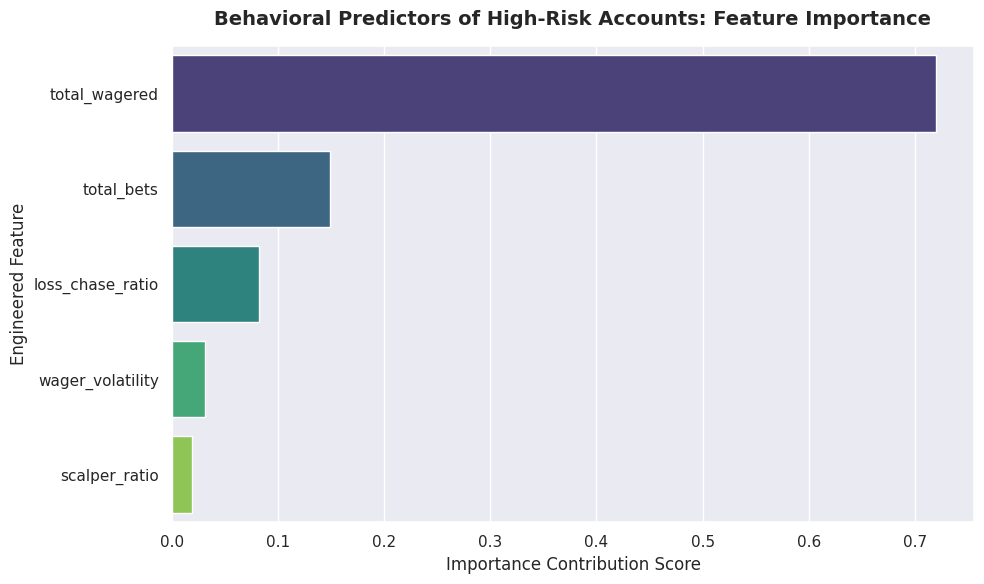

         Feature  Importance_Score
   total_wagered          0.719807
      total_bets          0.148498
loss_chase_ratio          0.081695
wager_volatility          0.030812
   scalper_ratio          0.019188


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = rf_model.feature_importances_
feature_names = X.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importance
}).sort_values(by='Importance_Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="darkgrid")

sns.barplot(
    x='Importance_Score', 
    y='Feature', 
    data=df_importance, 
    palette='viridis'
)

plt.title('Behavioral Predictors of High-Risk Accounts: Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Contribution Score', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.tight_layout()
plt.show()

print(df_importance.to_string(index=False))

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Loading feature matrix...")

features_to_drop = ['user_id', 'total_net_profit', 'net_loss', 'high_risk_target','total_bets','total_wagered']

X = DF.drop(columns=features_to_drop)
y = DF['high_risk_target']

print(f"Training Features: {list(X.columns)}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1 
)

print("\nTraining the Random Forest Classifier across behavioral types...")
rf_model.fit(X_train, y_train)
print("Model training completed successfully!")

y_pred = rf_model.predict(X_test)

print("\n================ MODEL EVALUATION REPORT ================")
print(classification_report(y_test, y_pred))
print("=========================================================")

Loading feature matrix...
Training Features: ['wager_volatility', 'loss_chase_ratio', 'scalper_ratio']

Training the Random Forest Classifier across behavioral types...
Model training completed successfully!

================ MODEL EVALUATION REPORT ================
              precision    recall  f1-score   support

           0       0.98      0.81      0.89      6100
           1       0.15      0.64      0.25       321

    accuracy                           0.81      6421
   macro avg       0.57      0.73      0.57      6421
weighted avg       0.94      0.81      0.86      6421



In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 95% regular / 5% high risk = 19:1 ratio
imbalance_ratio = 6100 / 321 

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio, 
    random_state=42
)

print("Training XGBoost Classifier...")
xgb_model.fit(X_train, y_train)
print(f"Training Features: {list(X.columns)}")

y_pred_xgb = xgb_model.predict(X_test)
print("\n================ XGBOOST EVALUATION REPORT ================")
print(classification_report(y_test, y_pred_xgb))

Training XGBoost Classifier...
Training Features: ['wager_volatility', 'loss_chase_ratio', 'scalper_ratio']

================ XGBOOST EVALUATION REPORT ================
              precision    recall  f1-score   support

           0       0.98      0.76      0.86      6100
           1       0.14      0.72      0.23       321

    accuracy                           0.76      6421
   macro avg       0.56      0.74      0.55      6421
weighted avg       0.94      0.76      0.83      6421



In [44]:
import numpy as np
import pandas as pd

y_scores = xgb_model.predict_proba(X_test)[:, 1]

#Testing different certainty thresholds to adjust accordingly
thresholds = [0.05,0.1,0.2,0.3,0.4,0.5, 0.6, 0.7, 0.8, 0.9]

print("============= THRESHOLD OPTIMIZATION MATRIX =============")
for t in thresholds:
    # If probability is above t, classify as 1, else 0
    y_pred_adjusted = (y_scores >= t).astype(int)
    
    # Calculate precision and recall manually for Class 1
    true_positives = np.sum((y_pred_adjusted == 1) & (y_test == 1))
    false_positives = np.sum((y_pred_adjusted == 1) & (y_test == 0))
    false_negatives = np.sum((y_pred_adjusted == 0) & (y_test == 1))
    
    precision = true_positives / (true_positives + false_positives + 1e-5)
    recall = true_positives / (true_positives + false_negatives + 1e-5)
    
    print(f"Threshold: {t*100:.0f}% Certainty | Precision: {precision:.2f} | Recall: {recall:.2f}")
print("=========================================================")

============= THRESHOLD OPTIMIZATION MATRIX =============
Threshold: 5% Certainty | Precision: 0.06 | Recall: 0.99
Threshold: 10% Certainty | Precision: 0.07 | Recall: 0.98
Threshold: 20% Certainty | Precision: 0.08 | Recall: 0.93
Threshold: 30% Certainty | Precision: 0.10 | Recall: 0.88
Threshold: 40% Certainty | Precision: 0.12 | Recall: 0.83
Threshold: 50% Certainty | Precision: 0.14 | Recall: 0.72
Threshold: 60% Certainty | Precision: 0.18 | Recall: 0.64
Threshold: 70% Certainty | Precision: 0.23 | Recall: 0.54
Threshold: 80% Certainty | Precision: 0.30 | Recall: 0.31
Threshold: 90% Certainty | Precision: 0.43 | Recall: 0.07


In [45]:
import joblib

#  save model 
joblib.dump(xgb_model, 'xgb_gambling_risk_model.pkl')

# Save test features 
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)

print(" complete")

 complete
